# <span style="color:blue"><b>PROYECTO FINAL</b></span>

# <span style="color:blue"><b>SISTEMA DE AUTENTICACIÓN MULTIPARTE DE CARTERAS</b></span>


#Integrantes
### ● Jesus Campos
### ● Marco Barrera



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### <span style="color:#800020"><b>Entrenamiento del Modelo para Autenticación de Carteras</b></span>

Se entrena un modelo de clasificación binaria para distinguir entre carteras genuinas y falsas usando EfficientNetB0, MobileNetV2 y ResNet50.
Se utiliza validación y early stopping para mejorar la generalización y evitar sobreajuste.

In [2]:
import zipfile, os, shutil

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")
print(os.listdir(DEST_DIR))

Dataset descomprimido
['genuine', 'fake']


In [3]:
import zipfile
import os
import shutil
import pandas as pd

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")

# extensiones válidas de imágenes
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

data = []

for root, dirs, files in os.walk(DEST_DIR):
    img_count = sum(1 for f in files if f.lower().endswith(IMG_EXT))

    if img_count > 0:
        rel_path = os.path.relpath(root, DEST_DIR)
        data.append([rel_path, img_count])

df = pd.DataFrame(data, columns=["Carpeta", "Cantidad_Imagenes"])

# ordenar por cantidad
df = df.sort_values(by="Cantidad_Imagenes", ascending=False)

# mostrar tabla
print(df.to_string(index=False))

# total general
print("\nTOTAL DE IMÁGENES:", df["Cantidad_Imagenes"].sum())

Dataset descomprimido
           Carpeta  Cantidad_Imagenes
 genuine/bag---boy               1632
genuine/bag---2.55                414
   fake/bag---2.55                200
    fake/bag---boy                200

TOTAL DE IMÁGENES: 2446


### <span style="color:#800020"><b>Modelo de Partes EfficientNetB3</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura EfficientNetB3 mediante transferencia de aprendizaje

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (300,300)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300,300,3)
)

base_model.trainable = False

model = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total: {total_time:.2f} segundos")
        print(f"Tiempo total: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[time_callback]
)

model.save("/content/drive/MyDrive/PI_II/modelo_EfficientNetB3.keras")

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.3485 - loss: 0.6753
Tiempo época 1: 134.26 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 134s 620ms/step - accuracy: 0.4609 - loss: 0.6655 - val_accuracy: 0.6544 - val_loss: 0.6485
Epoch 2/20
120/123 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6737 - loss: 0.5918
Tiempo época 2: 3.03 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6832 - loss: 0.6067 - val_accuracy: 0.7546 - val_loss: 0.5786
Epoch 3/20
122/123 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7229 - loss: 0.5518
Tiempo época 3: 3.03 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7312 - loss: 0.5683 - val_accuracy: 0.7853 - val_loss: 0.5341
Epo

### <span style="color:#800020"><b>Modelo de Partes MobileNetV3</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura MobileNetV3 mediante transferencia de aprendizaje

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_mobilev3 = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_mobilev3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total de entrenamiento: {total_time:.2f} segundos")
        print(f"Tiempo total de entrenamiento: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mobilev3 = model_mobilev3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, time_callback]
)

print("Mejor Val Accuracy MobileNetV3Large:",
      max(history_mobilev3.history["val_accuracy"]))

print("Mejor Val Loss MobileNetV3Large:",
      min(history_mobilev3.history["val_loss"]))

model_mobilev3.save(
    "/content/drive/MyDrive/PI_II/modelo_mobilenetv3_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_mobilev3.pkl", "wb") as f:
    pickle.dump(history_mobilev3.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6692 - loss: 0.6748
Tiempo época 1: 60.49 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 60s 310ms/step - accuracy: 0.6648 - loss: 0.6825 - val_accuracy: 0.6994 - val_loss: 0.5874
Epoch 2/20
122/123 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6425 - loss: 0.6223
Tiempo época 2: 1.68 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6704 - loss: 0.6105 - val_accuracy: 0.7853 - val_loss: 0.5158
Epoch 3/20
120/123 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7407 - loss: 0.5294
Tiempo época 3: 1.69 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7450 - loss: 0.5287 - val_accuracy: 0.8078 - val_loss: 0.4727
Epoch

### <span style="color:#800020"><b>Modelo de Partes ResNet50</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura ResNet50 mediante transferencia de aprendizaje

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_resnet = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total de entrenamiento: {total_time:.2f} segundos")
        print(f"Tiempo total de entrenamiento: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, time_callback]
)

print("Mejor Val Accuracy ResNet50:",
      max(history_resnet.history["val_accuracy"]))

print("Mejor Val Loss ResNet50:",
      min(history_resnet.history["val_loss"]))

model_resnet.save(
    "/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_resnet.pkl", "wb") as f:
    pickle.dump(history_resnet.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6240 - loss: 0.6851
Tiempo época 1: 24.67 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.6392 - loss: 0.6611 - val_accuracy: 0.6830 - val_loss: 0.5842
Epoch 2/20
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6840 - loss: 0.5721
Tiempo época 2: 2.19 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6898 - loss: 0.5975 - val_accuracy: 0.7403 - val_loss: 0.5022
Epoch 3/20
118/123 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7435 - loss: 0.4860
Tiempo época 3: 2.22 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7614 - loss: 0.4891 - val_accuracy: 0.8098 - val_loss: 0.4336
Epoch 

In [7]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import pandas as pd

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

model_eff = load_model("/content/drive/MyDrive/PI_II/modelo_EfficientNetB3.keras")
model_mobile = load_model("/content/drive/MyDrive/PI_II/modelo_mobilenetv3_logo_turnlock.keras")
model_resnet = load_model("/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras")

loss_eff, acc_eff = model_eff.evaluate(val_ds_300, verbose=0)
loss_mobile, acc_mobile = model_mobile.evaluate(val_ds_224, verbose=0)
loss_resnet, acc_resnet = model_resnet.evaluate(val_ds_224, verbose=0)

resultados = pd.DataFrame({
    "Modelo": ["ResNet50", "EfficientNetB3", "MobileNetV3"],
    "Accuracy": [acc_resnet, acc_eff, acc_mobile],
    "Loss": [loss_resnet, loss_eff, loss_mobile]
})

resultados["Accuracy (%)"] = resultados["Accuracy"] * 100
resultados["Error (%)"] = 100 - resultados["Accuracy (%)"]

resultados = resultados.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

resultados["Ranking"] = ["🥇", "🥈", "🥉"]

display(resultados)

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


,Modelo,Accuracy,Loss,Accuracy (%),Error (%),Ranking
0,ResNet50,0.936605,0.218566,93.660533,6.339467,🥇
1,MobileNetV3,0.928425,0.244403,92.842537,7.157463,🥈
2,EfficientNetB3,0.901841,0.325931,90.184051,9.815949,🥉


In [8]:
print("history" in globals())
print("history_resnet" in globals())
print("history_mobilev3" in globals())

True
True
True


**Precisión de Entrenamiento y Validación**

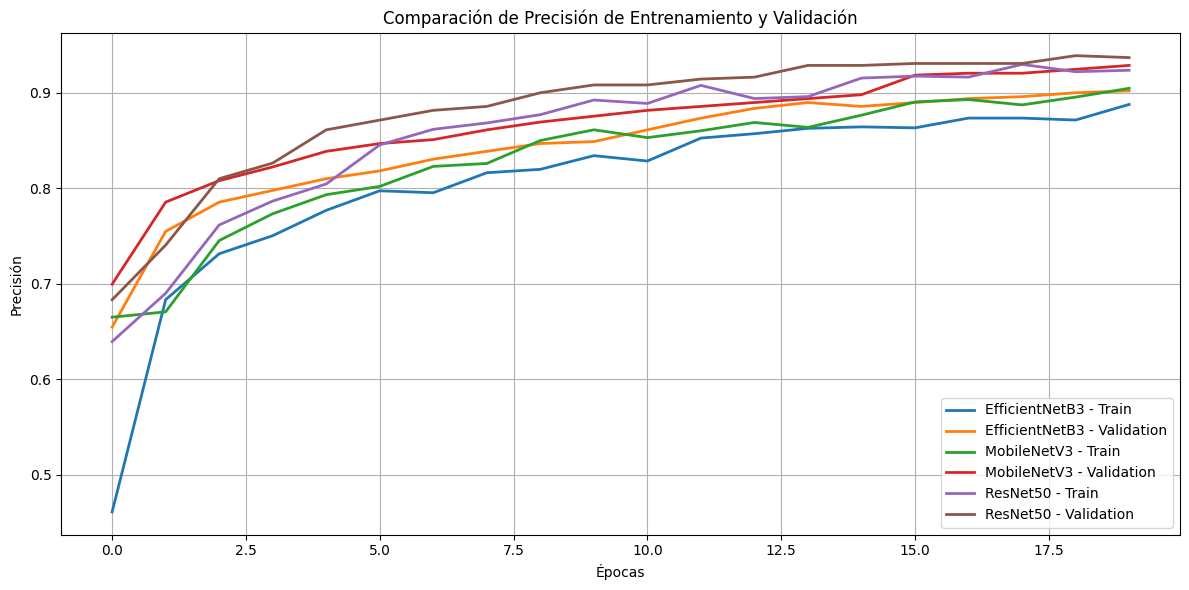

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['accuracy'],
         label='EfficientNetB3 - Train',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='EfficientNetB3 - Validation',
         linewidth=2)

plt.plot(history_mobilev3.history['accuracy'],
         label='MobileNetV3 - Train',
         linewidth=2)

plt.plot(history_mobilev3.history['val_accuracy'],
         label='MobileNetV3 - Validation',
         linewidth=2)

plt.plot(history_resnet.history['accuracy'],
         label='ResNet50 - Train',
         linewidth=2)

plt.plot(history_resnet.history['val_accuracy'],
         label='ResNet50 - Validation',
         linewidth=2)

plt.title('Comparación de Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

**Loss de Entrenamiento vs Validación**

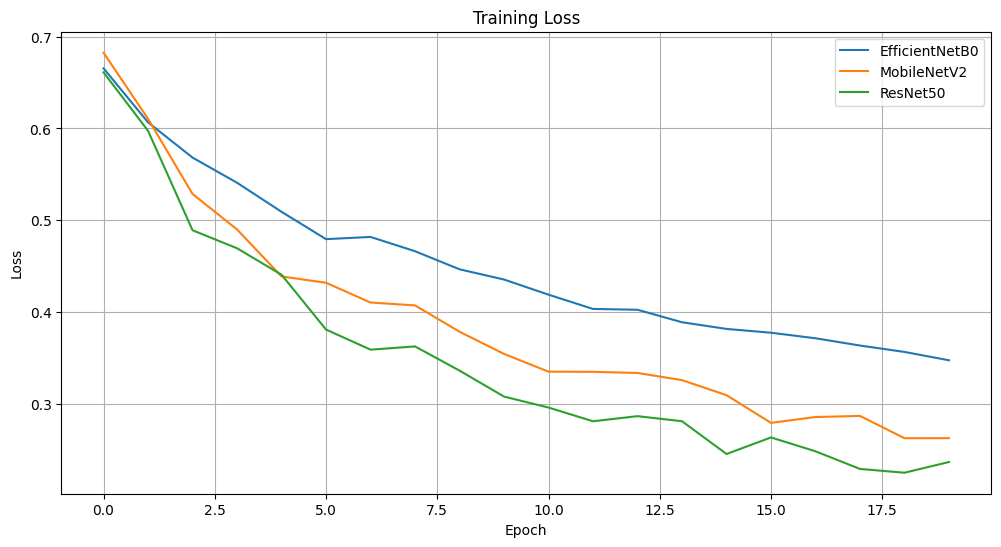

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['loss'], label='EfficientNetB0')
plt.plot(history_mobilev3.history['loss'], label='MobileNetV2')
plt.plot(history_resnet.history['loss'], label='ResNet50')

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
import pandas as pd

df_metricas = pd.DataFrame({
    "Modelo": ["EfficientNetB3", "MobileNetV3", "ResNet50"],
    "Mejor Val Accuracy": [
        max(history.history["val_accuracy"]),
        max(history_mobilev3.history["val_accuracy"]),
        max(history_resnet.history["val_accuracy"])
    ],
    "Mejor Val Loss": [
        min(history.history["val_loss"]),
        min(history_mobilev3.history["val_loss"]),
        min(history_resnet.history["val_loss"])
    ],
    "Épocas entrenadas": [
        len(history.history["accuracy"]),
        len(history_mobilev3.history["accuracy"]),
        len(history_resnet.history["accuracy"])
    ]
})

df_metricas["Accuracy (%)"] = df_metricas["Mejor Val Accuracy"] * 100
df_metricas["Error (%)"] = 100 - df_metricas["Accuracy (%)"]

df_metricas = df_metricas.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

df_metricas["Ranking"] = ["🥇", "🥈", "🥉"]

display(df_metricas)

,Modelo,Mejor Val Accuracy,Mejor Val Loss,Épocas entrenadas,Accuracy (%),Error (%),Ranking
0,ResNet50,0.938650,0.218566,20,93.865031,6.134969,🥇
1,MobileNetV3,0.928425,0.244403,20,92.842537,7.157463,🥈
2,EfficientNetB3,0.901841,0.325931,20,90.184051,9.815949,🥉


**# Comparativa de los 3 Modelos**

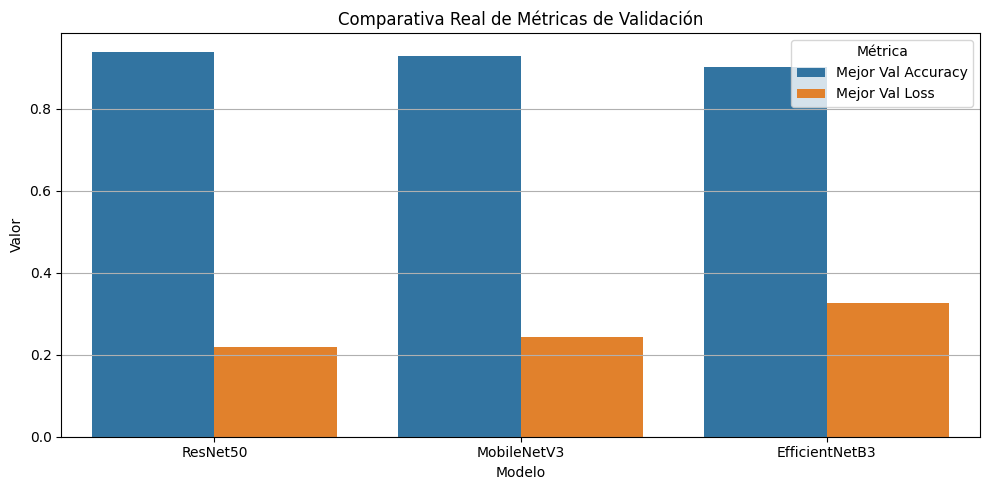

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_metricas.melt(
    id_vars="Modelo",
    value_vars=["Mejor Val Accuracy", "Mejor Val Loss"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparativa Real de Métricas de Validación")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Matriz de Confusión del Modelo de Autenticación de Partes**

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


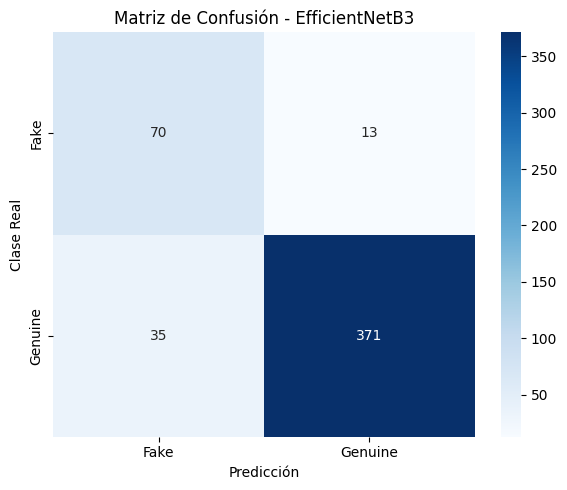


===== EfficientNetB3 =====
              precision    recall  f1-score   support

        Fake       0.67      0.84      0.74        83
     Genuine       0.97      0.91      0.94       406

    accuracy                           0.90       489
   macro avg       0.82      0.88      0.84       489
weighted avg       0.92      0.90      0.91       489



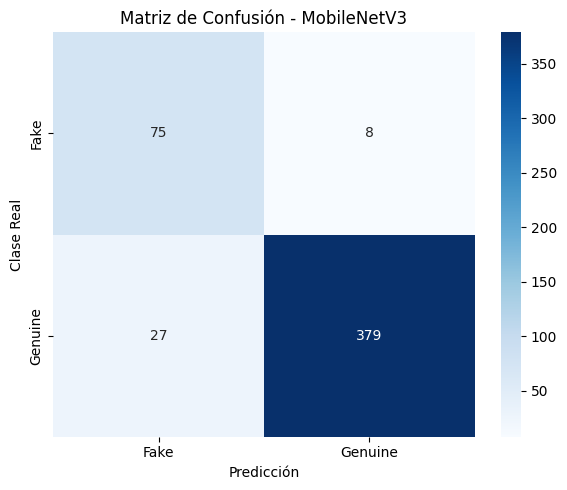


===== MobileNetV3 =====
              precision    recall  f1-score   support

        Fake       0.74      0.90      0.81        83
     Genuine       0.98      0.93      0.96       406

    accuracy                           0.93       489
   macro avg       0.86      0.92      0.88       489
weighted avg       0.94      0.93      0.93       489



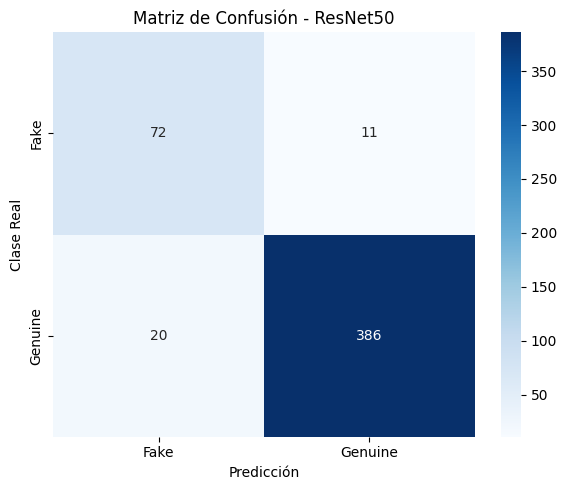


===== ResNet50 =====
              precision    recall  f1-score   support

        Fake       0.78      0.87      0.82        83
     Genuine       0.97      0.95      0.96       406

    accuracy                           0.94       489
   macro avg       0.88      0.91      0.89       489
weighted avg       0.94      0.94      0.94       489



In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

class_names = ['Fake', 'Genuine']

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

modelos = {
    "EfficientNetB3": (model_eff, val_ds_300),
    "MobileNetV3": (model_mobile, val_ds_224),
    "ResNet50": (model_resnet, val_ds_224)
}

for nombre, (modelo, dataset) in modelos.items():

    y_true = []
    y_prob = []

    for x_batch, y_batch in dataset:
        pred = modelo.predict(x_batch, verbose=0)
        y_prob.extend(pred.ravel())
        y_true.extend(y_batch.numpy().ravel())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Clase Real')
    plt.tight_layout()
    plt.show()

    print(f'\n===== {nombre} =====')
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

**K-Fold Cross Validation del Umbral Global**

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


,Modelo,Fold,Mejor Umbral,Accuracy,Precision,Recall,F1-Score
0,EfficientNetB3,1,0.60,0.836735,1.000000,0.804878,0.891892
1,EfficientNetB3,2,0.73,0.724490,1.000000,0.666667,0.800000
2,EfficientNetB3,3,0.64,0.857143,1.000000,0.827160,0.905405
3,EfficientNetB3,4,0.64,0.836735,1.000000,0.802469,0.890411
4,EfficientNetB3,5,0.50,0.917526,0.974026,0.925926,0.949367
5,MobileNetV3,1,0.50,0.938776,0.987179,0.939024,0.962500
6,MobileNetV3,2,0.54,0.908163,0.986486,0.901235,0.941935
7,MobileNetV3,3,0.50,0.969388,1.000000,0.962963,0.981132
8,MobileNetV3,4,0.50,0.948980,0.987179,0.950617,0.968553
9,MobileNetV3,5,0.67,0.824742,0.970588,0.814815,0.885906


Mejor Umbral                   Accuracy Precision    Recall  \
                       mean median       std      mean      mean      mean   
Modelo                                                                       
EfficientNetB3        0.622   0.64  0.083187  0.834526  0.994805  0.805420   
MobileNetV3           0.542   0.50  0.073621  0.918010  0.986287  0.913731   
ResNet50              0.680   0.79  0.164469  0.866926  0.992405  0.847004   

                F1-Score  
                    mean  
Modelo                    
EfficientNetB3  0.887415  
MobileNetV3     0.948005  
ResNet50        0.910867

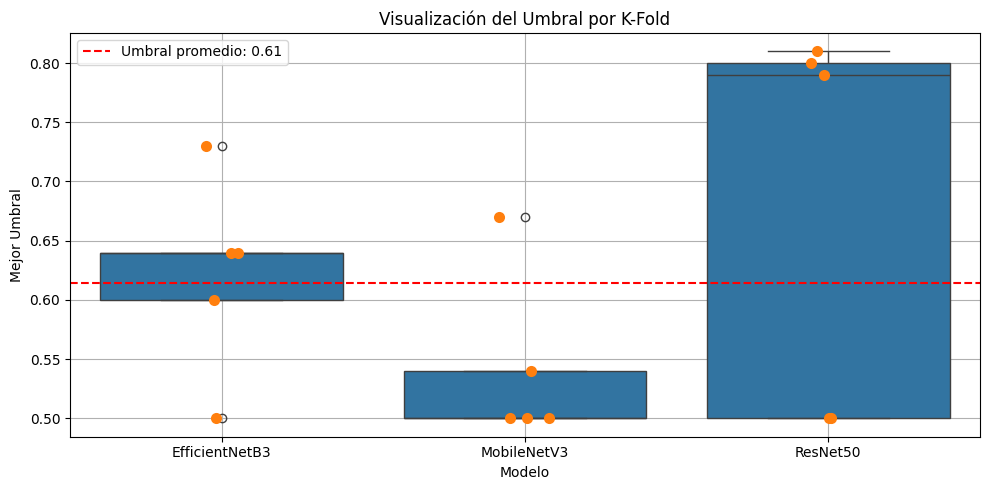

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

modelos = {
    "EfficientNetB3": (model_eff, val_ds_300),
    "MobileNetV3": (model_mobile, val_ds_224),
    "ResNet50": (model_resnet, val_ds_224)
}

umbrales = np.arange(0.50, 0.96, 0.01)

resultados = []

for nombre, (modelo, dataset) in modelos.items():

    y_true = []
    y_prob = []

    for x_batch, y_batch in dataset:
        pred = modelo.predict(x_batch, verbose=0)
        y_prob.extend(pred.ravel())
        y_true.extend(y_batch.numpy().ravel())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for fold, (_, test_idx) in enumerate(
        skf.split(y_prob, y_true),
        start=1
    ):

        y_true_fold = y_true[test_idx]
        y_prob_fold = y_prob[test_idx]

        mejor_score = -1
        mejor_umbral = 0
        mejor_accuracy = 0
        mejor_precision = 0
        mejor_recall = 0
        mejor_f1 = 0

        for umbral in umbrales:

            y_pred_fold = (y_prob_fold >= umbral).astype(int)

            accuracy = accuracy_score(y_true_fold, y_pred_fold)

            precision = precision_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            recall = recall_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            f1 = f1_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            score = (0.90 * precision) + (0.10 * recall)

            if score > mejor_score:
                mejor_score = score
                mejor_umbral = umbral
                mejor_accuracy = accuracy
                mejor_precision = precision
                mejor_recall = recall
                mejor_f1 = f1

        resultados.append([
            nombre,
            fold,
            round(mejor_umbral, 2),
            mejor_accuracy,
            mejor_precision,
            mejor_recall,
            mejor_f1
        ])

df_kfold = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "Fold",
        "Mejor Umbral",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

display(df_kfold)

resumen = (
    df_kfold
    .groupby("Modelo")
    .agg({
        "Mejor Umbral": ["mean", "median", "std"],
        "Accuracy": "mean",
        "Precision": "mean",
        "Recall": "mean",
        "F1-Score": "mean"
    })
)

display(resumen)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_kfold,
    x="Modelo",
    y="Mejor Umbral"
)

sns.stripplot(
    data=df_kfold,
    x="Modelo",
    y="Mejor Umbral",
    size=8,
    jitter=True
)

plt.axhline(
    df_kfold["Mejor Umbral"].mean(),
    color="red",
    linestyle="--",
    label=f'Umbral promedio: {df_kfold["Mejor Umbral"].mean():.2f}'
)

plt.title("Visualización del Umbral por K-Fold")
plt.xlabel("Modelo")
plt.ylabel("Mejor Umbral")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
!pip install shap -q

**Comparación baseline vs. modelo actual**

In [30]:
import time
import os
import psutil
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


MODELOS_PRUEBA = {
    "Baseline - MobileNetV3": model_mobile,
    "Modelo actual - ResNet50": model_resnet
}


X_test = []
y_test = []

for x_batch, y_batch in val_ds_224:
    X_test.append(x_batch.numpy())
    y_test.append(y_batch.numpy())

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test).astype(int)

print("Imágenes de prueba:", len(X_test))

Imágenes de prueba: 489


**Latencia p50, p95, throughput y consumo**

In [31]:
def evaluar_rendimiento(nombre, modelo, X, y, umbral=0.5):
    proceso = psutil.Process(os.getpid())


    for i in range(min(10, len(X))):
        _ = modelo(X[i:i+1], training=False)

    memoria_inicial = proceso.memory_info().rss / (1024 ** 2)

    latencias_ms = []
    probabilidades = []

    inicio_total = time.perf_counter()

    for imagen in X:
        entrada = np.expand_dims(imagen, axis=0)

        inicio = time.perf_counter()
        prediccion = modelo(entrada, training=False).numpy().ravel()[0]
        fin = time.perf_counter()

        probabilidades.append(prediccion)
        latencias_ms.append((fin - inicio) * 1000)

    tiempo_total = time.perf_counter() - inicio_total

    memoria_final = proceso.memory_info().rss / (1024 ** 2)

    probabilidades = np.array(probabilidades)
    predicciones = (probabilidades >= umbral).astype(int)
    latencias_ms = np.array(latencias_ms)

    return {
        "Configuración": nombre,
        "Accuracy": accuracy_score(y, predicciones),
        "Precision": precision_score(y, predicciones, zero_division=0),
        "Recall": recall_score(y, predicciones, zero_division=0),
        "F1": f1_score(y, predicciones, zero_division=0),
        "p50_ms": np.percentile(latencias_ms, 50),
        "p95_ms": np.percentile(latencias_ms, 95),
        "Req_s": len(X) / tiempo_total,
        "Errores_pct": np.mean(predicciones != y) * 100,
        "RAM_MB": max(memoria_final - memoria_inicial, 0),
        "Latencias": latencias_ms
    }


resultados_rendimiento = []
latencias_por_modelo = {}

for nombre, modelo in MODELOS_PRUEBA.items():
    resultado = evaluar_rendimiento(
        nombre=nombre,
        modelo=modelo,
        X=X_test,
        y=y_test,
        umbral=0.5
    )

    latencias_por_modelo[nombre] = resultado.pop("Latencias")
    resultados_rendimiento.append(resultado)

df_rendimiento = pd.DataFrame(resultados_rendimiento)

display(
    df_rendimiento.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1": 4,
        "p50_ms": 2,
        "p95_ms": 2,
        "Req_s": 2,
        "Errores_pct": 2,
        "RAM_MB": 2
    })
)

,Configuración,Accuracy,Precision,Recall,F1,p50_ms,p95_ms,Req_s,Errores_pct,RAM_MB
0,Baseline - MobileNetV3,0.9284,0.9793,0.9335,0.9559,175.23,179.58,5.69,7.16,0.03
1,Modelo actual - ResNet50,0.9366,0.9723,0.9507,0.9614,223.75,230.01,4.46,6.34,0.02


**Modelo optimizado con tf.function**

In [32]:
@tf.function(
    input_signature=[
        tf.TensorSpec(shape=[None, 224, 224, 3], dtype=tf.float32)
    ],
    reduce_retracing=True
)
def resnet_optimizado(x):
    return model_resnet(x, training=False)


def evaluar_modelo_optimizado(X, y, umbral=0.5):
    proceso = psutil.Process(os.getpid())

    # Warm-up
    for i in range(min(10, len(X))):
        _ = resnet_optimizado(
            tf.convert_to_tensor(X[i:i+1], dtype=tf.float32)
        )

    memoria_inicial = proceso.memory_info().rss / (1024 ** 2)

    latencias_ms = []
    probabilidades = []

    inicio_total = time.perf_counter()

    for imagen in X:
        entrada = tf.convert_to_tensor(
            np.expand_dims(imagen, axis=0),
            dtype=tf.float32
        )

        inicio = time.perf_counter()
        prediccion = resnet_optimizado(entrada).numpy().ravel()[0]
        fin = time.perf_counter()

        probabilidades.append(prediccion)
        latencias_ms.append((fin - inicio) * 1000)

    tiempo_total = time.perf_counter() - inicio_total

    memoria_final = proceso.memory_info().rss / (1024 ** 2)

    probabilidades = np.array(probabilidades)
    predicciones = (probabilidades >= umbral).astype(int)
    latencias_ms = np.array(latencias_ms)

    return {
        "Configuración": "Modelo optimizado - ResNet50",
        "Accuracy": accuracy_score(y, predicciones),
        "Precision": precision_score(y, predicciones, zero_division=0),
        "Recall": recall_score(y, predicciones, zero_division=0),
        "F1": f1_score(y, predicciones, zero_division=0),
        "p50_ms": np.percentile(latencias_ms, 50),
        "p95_ms": np.percentile(latencias_ms, 95),
        "Req_s": len(X) / tiempo_total,
        "Errores_pct": np.mean(predicciones != y) * 100,
        "RAM_MB": max(memoria_final - memoria_inicial, 0),
        "Latencias": latencias_ms
    }


resultado_optimizado = evaluar_modelo_optimizado(
    X_test,
    y_test,
    umbral=0.5
)

latencias_por_modelo["Modelo optimizado - ResNet50"] = (
    resultado_optimizado.pop("Latencias")
)

df_rendimiento = pd.concat(
    [
        df_rendimiento,
        pd.DataFrame([resultado_optimizado])
    ],
    ignore_index=True
)

display(df_rendimiento.round(4))

,Configuración,Accuracy,Precision,Recall,F1,p50_ms,p95_ms,Req_s,Errores_pct,RAM_MB
0,Baseline - MobileNetV3,0.9284,0.9793,0.9335,0.9559,175.2315,179.5761,5.6859,7.1575,0.0273
1,Modelo actual - ResNet50,0.9366,0.9723,0.9507,0.9614,223.7527,230.0124,4.4564,6.3395,0.0195
2,Modelo optimizado - ResNet50,0.9366,0.9723,0.9507,0.9614,7.3584,8.4454,124.2363,6.3395,0.0000


**Prueba de throughput con batching**

In [33]:
def medir_batching(modelo, X, batch_sizes=(1, 8, 16, 32)):
    resultados = []

    for batch_size in batch_sizes:
        dataset = tf.data.Dataset.from_tensor_slices(X).batch(batch_size)

        # Warm-up
        primer_batch = next(iter(dataset))
        _ = modelo(primer_batch, training=False)

        cantidad = 0
        inicio = time.perf_counter()

        for batch in dataset:
            _ = modelo(batch, training=False)
            cantidad += len(batch)

        tiempo = time.perf_counter() - inicio

        resultados.append({
            "Batch_size": batch_size,
            "Imágenes": cantidad,
            "Tiempo_total_s": tiempo,
            "Throughput_req_s": cantidad / tiempo
        })

    return pd.DataFrame(resultados)


df_batching = medir_batching(
    model_resnet,
    X_test,
    batch_sizes=(1, 8, 16, 32)
)

display(df_batching.round(3))

,Batch_size,Imágenes,Tiempo_total_s,Throughput_req_s
0,1,489,111.275,4.395
1,8,489,14.182,34.479
2,16,489,7.465,65.508
3,32,489,3.716,131.608


**Pruebas de robustez**

In [34]:
def aplicar_perturbacion(imagen, tipo):
    imagen = tf.convert_to_tensor(imagen, dtype=tf.float32)

    if tipo == "Original":
        salida = imagen

    elif tipo == "Oscura":
        salida = tf.image.adjust_brightness(imagen, delta=-60)

    elif tipo == "Ruido":
        ruido = tf.random.normal(
            tf.shape(imagen),
            mean=0.0,
            stddev=25.0
        )
        salida = imagen + ruido

    elif tipo == "Rotada":
        salida = tf.image.rot90(imagen)

    elif tipo == "Contraste bajo":
        salida = tf.image.adjust_contrast(imagen, contrast_factor=0.5)

    else:
        raise ValueError(f"Perturbación desconocida: {tipo}")

    return tf.clip_by_value(salida, 0, 255)


def evaluar_robustez(modelo, X, y, umbral=0.5):
    perturbaciones = [
        "Original",
        "Oscura",
        "Ruido",
        "Rotada",
        "Contraste bajo"
    ]

    resultados = []

    for tipo in perturbaciones:
        X_modificado = np.array([
            aplicar_perturbacion(imagen, tipo).numpy()
            for imagen in X
        ])

        probabilidades = modelo.predict(
            X_modificado,
            batch_size=16,
            verbose=0
        ).ravel()

        predicciones = (probabilidades >= umbral).astype(int)

        resultados.append({
            "Entrada": tipo,
            "Accuracy": accuracy_score(y, predicciones),
            "Precision": precision_score(
                y,
                predicciones,
                zero_division=0
            ),
            "Recall": recall_score(
                y,
                predicciones,
                zero_division=0
            ),
            "F1": f1_score(
                y,
                predicciones,
                zero_division=0
            ),
            "Errores_pct": np.mean(predicciones != y) * 100
        })

    return pd.DataFrame(resultados)


df_robustez = evaluar_robustez(
    model_resnet,
    X_test,
    y_test,
    umbral=0.5
)

display(df_robustez.round(4))

,Entrada,Accuracy,Precision,Recall,F1,Errores_pct
0,Original,0.9366,0.9723,0.9507,0.9614,6.3395
1,Oscura,0.8487,0.9770,0.8374,0.9019,15.1329
2,Ruido,0.6012,0.9817,0.5296,0.6880,39.8773
3,Rotada,0.8671,0.9697,0.8670,0.9155,13.2924
4,Contraste bajo,0.8998,0.9661,0.9113,0.9379,10.0204


**Gráficos de latencia**

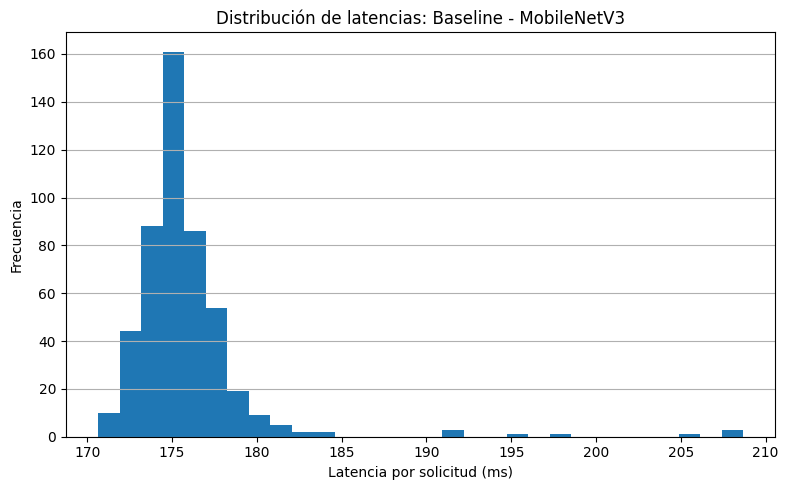

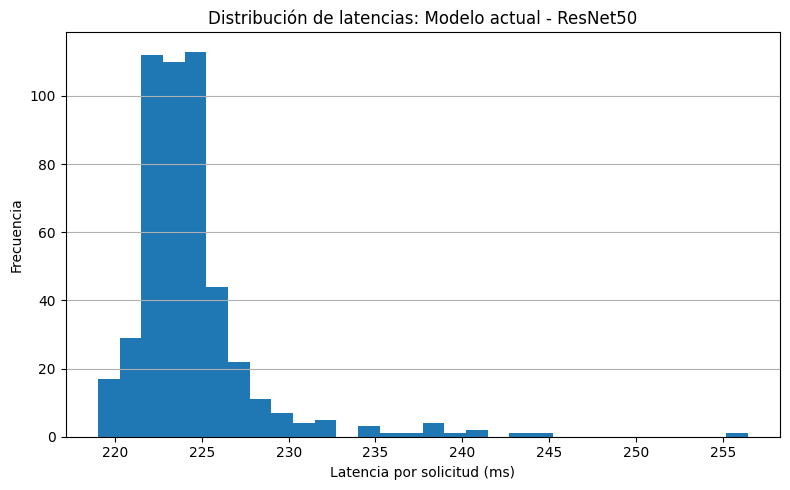

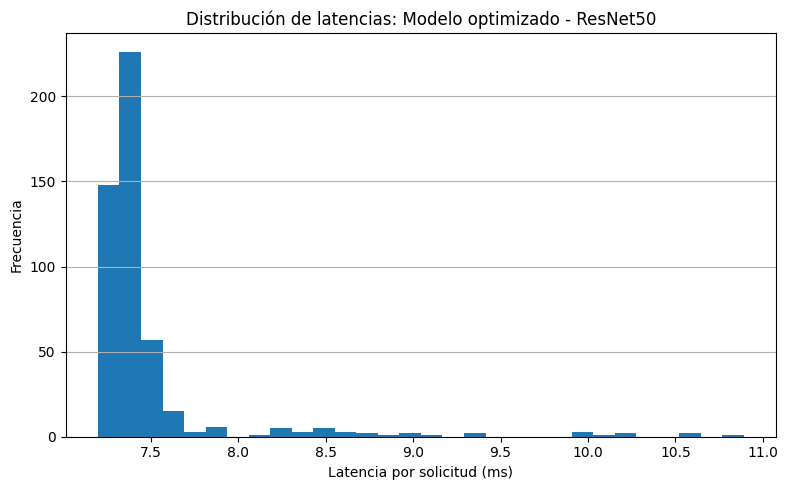

In [35]:
import matplotlib.pyplot as plt

for nombre, latencias in latencias_por_modelo.items():
    plt.figure(figsize=(8, 5))
    plt.hist(latencias, bins=30)
    plt.xlabel("Latencia por solicitud (ms)")
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de latencias: {nombre}")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

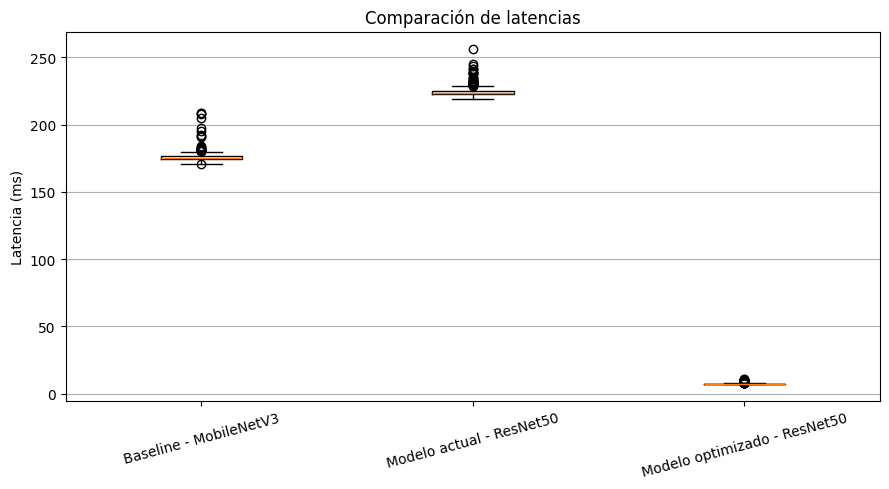

In [36]:
plt.figure(figsize=(9, 5))

datos_boxplot = list(latencias_por_modelo.values())
nombres_boxplot = list(latencias_por_modelo.keys())

plt.boxplot(datos_boxplot, tick_labels=nombres_boxplot)
plt.ylabel("Latencia (ms)")
plt.title("Comparación de latencias")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.show()